In [1]:
include("MiniCollectiveSpins.jl")
using PyPlot
using Statistics
using JLD2
using ProgressBars

In [2]:
function compute_Ω(I, γ, ω)
    return (6π*ustrip(c_0)^2*γ .* I / (ω^3 * ustrip(ħ))).^(1/2)
end

function decay_rate_indep(N, γ, Ω)
    return γ*N ./ (2 .+ (γ ./ Ω).^2)
end

decay_rate_indep (generic function with 1 method)

### Define the system

In [18]:
# Parameters
N = 30
# sat = vcat([0.1:0.1:0.9;], [1:35;])
sat = [20.1:5:40.1;]
sat_computed = sat
pathname_density_distrib = "Groundstate_Bext_90_deg_as_98.h5"
@load "Density_distributions\\$(pathname_density_distrib[1:end-3])_N_$(N).jld2" CS_densities_cuts_norm
n_list = 10*CS_densities_cuts_norm[1:100:length(CS_densities_cuts_norm)]  # List of densities to simulate.

# Quantization axis along z
e = [0, 0, 1.]

# Constants
λ = 421e-9
γ = 32.7e6 # In Hz
@load "op_list/op_list_$N.jdl2" op_list;

In [4]:
println("Nbr of Atoms simulated = $(length(n_list)*N)")

Nbr of Atoms simulated = 780


### Recover data from simulations

In [19]:
list_t_N, popup_t_N, sol_t_N, nbr_error_N = [], [], [], []

for (i, s) in ProgressBar(enumerate(sat_computed))
    line = []
    @load "solutions/Sat_$(minimum(sat))to$(maximum(sat))_n0_$(round(mean(n_list), digits=2))_N_$N/sol_N_$(N)_Sat_$(sat[i])_stripe_distribution_$(pathname_density_distrib[1:end-3])_n0_$(round(mean(n_list), digits=2)).jld2" N n_list sat sol_tasks
    list_t, popup_t, sol_t =  [vcat([st[i] for st in sol_tasks]...) for i = 1:3]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(sol_t_N, sol_t), push!(nbr_error_N, sum(vcat([st[4] for st in sol_tasks]...)))
end


0.0%┣                                                ┫ 0/5 [00:00<00:00, -0s/it]
20.0%┣████████▋                                  ┫ 1/5 [00:00<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████████┫ 5/5 [00:00<00:00, 20it/s]
100.0%┣██████████████████████████████████████████████┫ 5/5 [00:00<00:00, 20it/s]


# Plots of the time evolution

0.0%┣                                                ┫ 0/4 [00:00<00:00, -0s/it]
25.0%┣██████████▊                                ┫ 1/4 [00:00<Inf:Inf, InfGs/it]
100.0%┣███████████████████████████████████████████████┫ 4/4 [00:00<00:00, 6it/s]
100.0%┣███████████████████████████████████████████████┫ 4/4 [00:00<00:00, 6it/s]


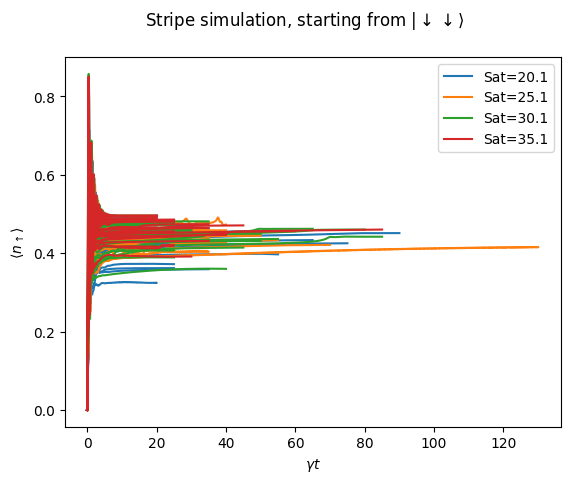

In [6]:
close("all")
fig, ax = subplots()

for (i, s) in ProgressBar(enumerate(sat_computed))
    line = []
    for j in 1:length(popup_t_N[i])
        if line == []
            line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="Sat=$(s)")
        else
            ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, color=line.get_color()) # marker="o", markersize=1,
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("Stripe simulation, starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

### Density dependancy

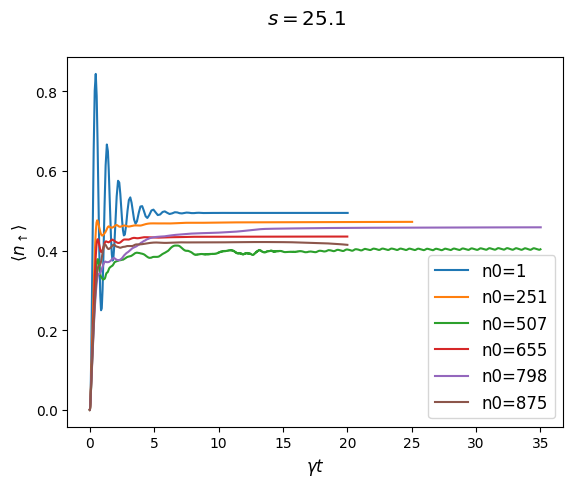

In [7]:
close("all")
fig, ax = subplots()

i = 2 # Saturation intensity

rc("font", size=12)

line = []
for j in 1:5:length(popup_t_N[i])
    line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="n0=$(round(Int, n_list[j]))")
end


ax.set_xlabel(L"$\gamma t$", fontsize=12)
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $", fontsize=12)
ax.legend()

suptitle(L"$s=$"*"$(sat[i])")
pygui(false); gcf();
# pygui(true); show()
savefig("Time_evol.pdf")

# Mean of the SS

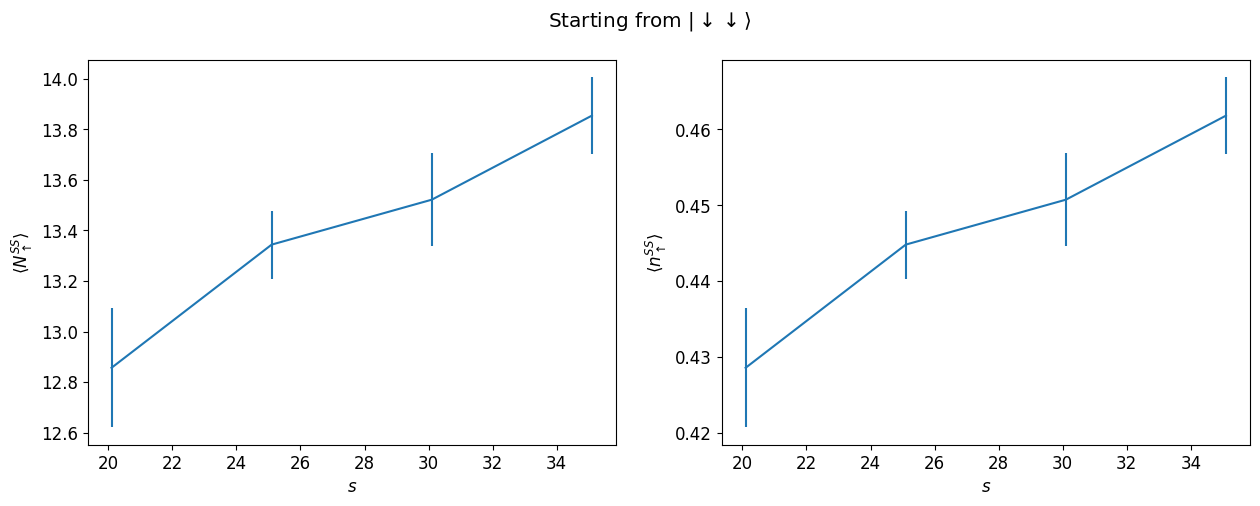

In [8]:
mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i])] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i])] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(sat_computed, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i]) for i = 1:length(sat_computed)]))
axes[1].set_xlabel(L"s")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(sat_computed, mean_SS./N, yerr=std_SS ./ (N .* sqrt.([length(popup_t_N[i]) for i = 1:length(sat_computed)])))
axes[2].set_xlabel(L"s")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")

suptitle("Starting from "*L"$|\downarrow \downarrow \rangle $")

pygui(false); gcf();
# pygui(true); show()

# Compute $\gamma_{SE}$ from the SR SS

In [20]:
I_SE_SR_SS = zeros(ComplexF64, (length(sat_computed), length(n_list)))

for (i, s) in enumerate(sat_computed)
    for j in 1:length(n_list)
        
        if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
            sol_SS = sol_t_N[i][j][end]
        else
            sol_SS = sol_t_N[i][j] # Only the SS was saved
        end

        for a = 1:N
            I_SE_SR_SS[i, j] += sol_SS[a] # The decay rates are normalized by γ
        end
    end
end
I_SE_SR_SS = real.(I_SE_SR_SS); # This is the mean decay rate of SE in the full stripe

# Compute $\gamma_{SR}$ from the SR SS

In [21]:
I_SR_SR_SS = zeros(ComplexF64, (length(sat_computed), length(n_list)))

for (i, s) in ProgressBar(enumerate(sat_computed))
    for j in 1:length(n_list)
        @load "r0/Sat_$(minimum(sat))to$(maximum(sat))_n0_$(round(mean(n_list), digits=2))_N_$N/r0_N_$(N)_density_idx_$(i)_sat_$(round(sat[i], digits=1))_n0_$(round(mean(n_list), digits=2)).jdl2" r0 L

        system = SpinCollection(r0, e, gammas=1.)
        Γ_CS = GammaMatrix(system)
        
        if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
            sol_SS = sol_t_N[i][j][end]
        else
            sol_SS = sol_t_N[i][j] # Only the SS was saved
        end

        for a = 1:N
            for b = 1:N
                if b > a # Correlated decay
                    corr = [21*10^(floor(Int, log10(a))+1)+a, 12*10^(floor(Int, log10(b))+1)+b]
                    try
                        I_SR_SR_SS[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                    catch
                        println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                    end
                end
            end
        end
    end
end
I_SR_SR_SS = real.(I_SR_SR_SS); # This is the mean decay rate of SR in the full stripe

0.0%┣                                                ┫ 0/5 [00:00<00:00, -0s/it]
20.0%┣████████▋                                  ┫ 1/5 [00:02<Inf:Inf, InfGs/it]
40.0%┣███████████████████▏                            ┫ 2/5 [00:04<00:11, 4s/it]
60.0%┣████████████████████████████▉                   ┫ 3/5 [00:05<00:05, 3s/it]
80.0%┣██████████████████████████████████████▍         ┫ 4/5 [00:07<00:02, 2s/it]
100.0%┣███████████████████████████████████████████████┫ 5/5 [00:09<00:00, 2s/it]
100.0%┣███████████████████████████████████████████████┫ 5/5 [00:09<00:00, 2s/it]


In [22]:
Itot = I_SE_SR_SS .+ I_SR_SR_SS;

In [23]:
Itot_stripe = sum(Itot, dims=2) * γ
I_SE_SR_SS_stripe = sum(I_SE_SR_SS, dims=2) * γ
I_SR_SR_SS_stripe = sum(I_SR_SR_SS, dims=2) * γ;

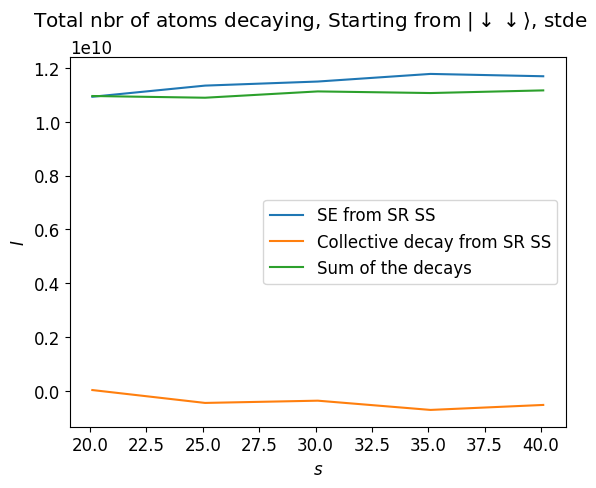

In [24]:
close("all")
fig = subplots()

plot(sat_computed, I_SE_SR_SS_stripe, label="SE from SR SS")
plot(sat_computed, I_SR_SR_SS_stripe, label="Collective decay from SR SS")
plot(sat_computed, Itot_stripe, label="Sum of the decays")

xlabel(L"s")
ylabel(L"$I$")

suptitle("Total nbr of atoms decaying, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()

# pygui(true); show()
pygui(false);

In [25]:
if !isdir("Itot")
    mkdir("Itot")
end
@save "Itot/Itot_N_$(N)_Sat_$(minimum(sat))to$(maximum(sat))_n0_$(round(mean(n_list), digits=2))_decay_rate_up_down.jdl2" sat sat_computed n_list Itot_stripe I_SE_SR_SS_stripe I_SR_SR_SS_stripe nbr_error_N

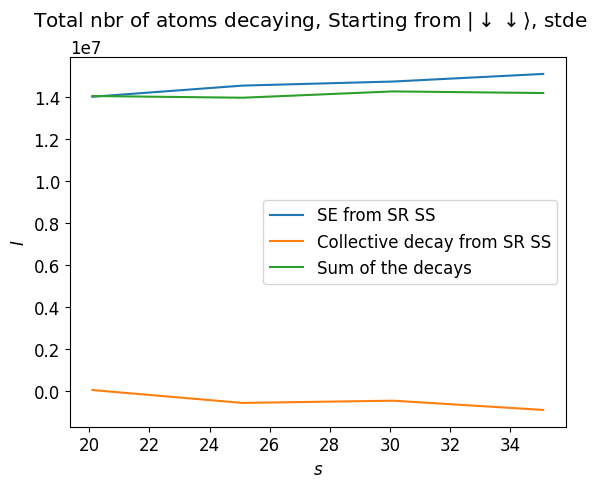

In [15]:
close("all")
fig = subplots()

plot(sat_computed, I_SE_SR_SS_stripe/(N*length(n_list)), label="SE from SR SS")
plot(sat_computed, I_SR_SR_SS_stripe/(N*length(n_list)), label="Collective decay from SR SS")
plot(sat_computed, Itot_stripe/(N*length(n_list)), label="Sum of the decays")

xlabel(L"s")
ylabel(L"$I$")

suptitle("Total nbr of atoms decaying, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()

# pygui(true); show()
pygui(false);

### SE

In [16]:
function decay_atoms_indep_V3(sat)
    return 1/2 .* 1 ./ (1 .+ 1 ./sat)
end

decay_atoms_indep_V3 (generic function with 1 method)

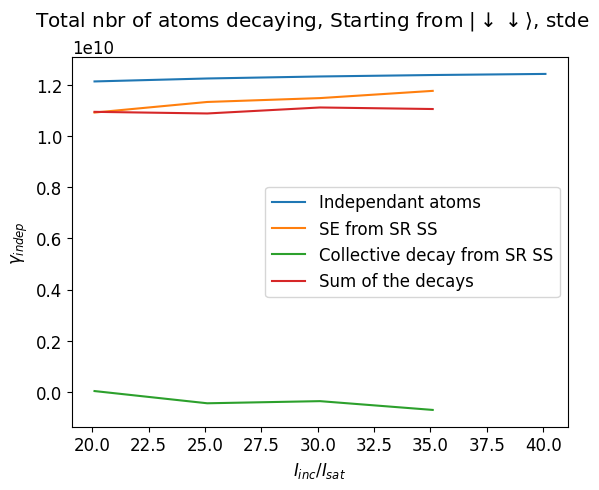

In [17]:
close("all")
figure = subplots()
plot(sat, decay_atoms_indep_V3(sat)*γ*(N*length(n_list)), label="Independant atoms")

plot(sat_computed, I_SE_SR_SS_stripe, label="SE from SR SS")
plot(sat_computed, I_SR_SR_SS_stripe, label="Collective decay from SR SS")
plot(sat_computed, Itot_stripe, label="Sum of the decays")

xlabel(L"s")
ylabel(L"$I$")

suptitle("Total nbr of atoms decaying, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()

# pygui(true); show()
pygui(false);

xlabel(L"$I_{inc}/I_{sat}$")
ylabel(L"\gamma_{indep}")
# ylabel(L"\sum\gamma_{indep}/\gamma")
pygui(false);